In [23]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

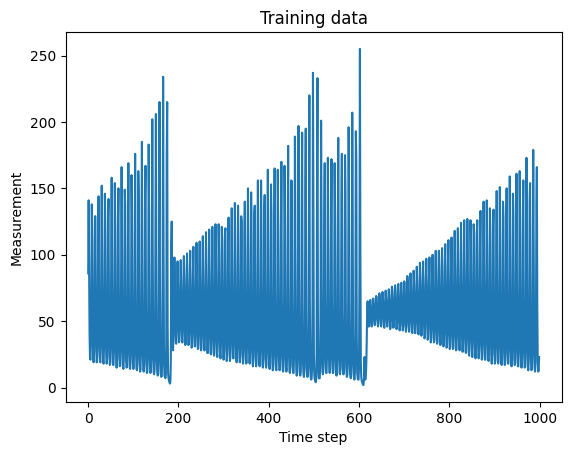

In [24]:
mat = scipy.io.loadmat("Xtrain.mat")
x = mat["Xtrain"].flatten()

plt.plot(x)
plt.title("Training data")
plt.xlabel("Time step")
plt.ylabel("Measurement")
plt.show()

In [25]:
split = int(0.8 * len(x))

train = x[:split]
val = x[split:]

In [26]:
windows = [5, 10, 20, 50]

best_w = None
best_mse = float("inf")

for w in windows:
    preds = []

    for i in range(split, len(x)):
        previous_values = x[i-w:i]
        pred = np.mean(previous_values)
        preds.append(pred)

    mse = mean_squared_error(x[split:], preds)

    print(f"w={w}, mse={mse:.3f}")

    if mse < best_mse:
        best_mse = mse
        best_w = w

print("Best window:", best_w)

w=5, mse=3476.371
w=10, mse=2130.064
w=20, mse=2270.191
w=50, mse=2039.167
Best window: 50


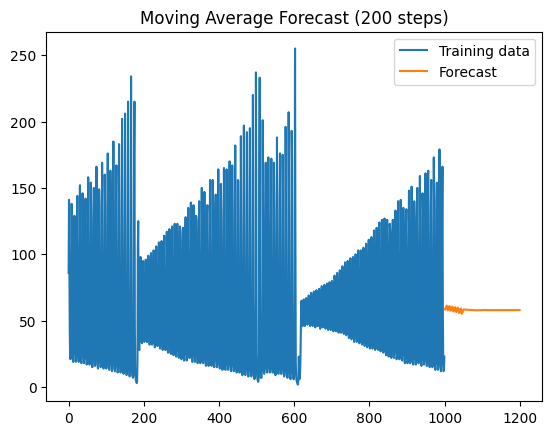

In [27]:
history = list(x[-best_w:])
future = []

for _ in range(200):
    pred = np.mean(history)
    future.append(pred)
    
    history.append(pred)
    history.pop(0)

future = np.array(future)

plt.plot(x, label="Training data")
plt.plot(range(len(x), len(x)+200), future, label="Forecast")
plt.legend()
plt.title("Moving Average Forecast (200 steps)")
plt.show()